# Projet 7 - Implémentez un modèle de scoring
Utilisation d'un Kernel pour gagner du temps sur le préprocessing et le feature engineering du dataset.
## Imports

In [1]:
import numpy as np
import pandas as pd
import gc
import time
from contextlib import contextmanager
from lightgbm import LGBMClassifier
from sklearn.metrics import f1_score, roc_auc_score, roc_curve, auc, confusion_matrix, classification_report
from sklearn.model_selection import KFold, StratifiedKFold, learning_curve
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC, SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import make_pipeline
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.preprocessing import StandardScaler, OneHotEncoder, MinMaxScaler
from sklearn.compose import make_column_transformer, make_column_selector
from sklearn.impute import KNNImputer, SimpleImputer
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [2]:
pd.set_option('display.max_row', 800)

## Accès aux données

In [3]:
chemin = "G:/Mon Drive/Yann Pham-Van - Data Scientist - OpenClassrooms/Projet7-Implémentez un modèle de scoring/input/"

## Fonctions

In [4]:
@contextmanager
def timer(title):
    t0 = time.time()
    yield
    print("{} - done in {:.0f}s".format(title, time.time() - t0))

# One-hot encoding for categorical columns with get_dummies
def one_hot_encoder(df, nan_as_category = True):
    original_columns = list(df.columns)
    categorical_columns = [col for col in df.columns if df[col].dtype == 'object']
    df = pd.get_dummies(df, columns= categorical_columns, dummy_na= nan_as_category, dtype=int)
    new_columns = [c for c in df.columns if c not in original_columns]
    return df, new_columns

# Preprocess application_train.csv and application_test.csv
def application_train_test(num_rows = None, nan_as_category = False):
    # Read data and merge
    df = pd.read_csv(chemin+'application_train.csv', nrows= num_rows)
    test_df = pd.read_csv(chemin+'application_test.csv', nrows= num_rows)
    print("Train samples: {}, test samples: {}".format(len(df), len(test_df)))
    # df = df.append(test_df).reset_index()
    df = pd.concat([df, test_df], ignore_index=True)
    # Optional: Remove 4 applications with XNA CODE_GENDER (train set)
    df = df[df['CODE_GENDER'] != 'XNA']
    
    # Categorical features with Binary encode (0 or 1; two categories)
    for bin_feature in ['CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY']:
        df[bin_feature], uniques = pd.factorize(df[bin_feature])
    # Categorical features with One-Hot encode
    df, cat_cols = one_hot_encoder(df, nan_as_category)
    
    # NaN values for DAYS_EMPLOYED: 365.243 -> nan
    df['DAYS_EMPLOYED'].replace(365243, np.nan, inplace= True)
    # Some simple new features (percentages)
    df['DAYS_EMPLOYED_PERC'] = df['DAYS_EMPLOYED'] / df['DAYS_BIRTH']
    df['INCOME_CREDIT_PERC'] = df['AMT_INCOME_TOTAL'] / df['AMT_CREDIT']
    df['INCOME_PER_PERSON'] = df['AMT_INCOME_TOTAL'] / df['CNT_FAM_MEMBERS']
    df['ANNUITY_INCOME_PERC'] = df['AMT_ANNUITY'] / df['AMT_INCOME_TOTAL']
    df['PAYMENT_RATE'] = df['AMT_ANNUITY'] / df['AMT_CREDIT']
    del test_df
    gc.collect()
    return df

# Preprocess bureau.csv and bureau_balance.csv
def bureau_and_balance(num_rows = None, nan_as_category = True):
    bureau = pd.read_csv(chemin+'bureau.csv', nrows = num_rows)
    bb = pd.read_csv(chemin+'bureau_balance.csv', nrows = num_rows)
    bb, bb_cat = one_hot_encoder(bb, nan_as_category)
    bureau, bureau_cat = one_hot_encoder(bureau, nan_as_category)
    
    # Bureau balance: Perform aggregations and merge with bureau.csv
    bb_aggregations = {'MONTHS_BALANCE': ['min', 'max', 'size']}
    for col in bb_cat:
        bb_aggregations[col] = ['mean']
    bb_agg = bb.groupby('SK_ID_BUREAU').agg(bb_aggregations)
    bb_agg.columns = pd.Index([e[0] + "_" + e[1].upper() for e in bb_agg.columns.tolist()])
    bureau = bureau.join(bb_agg, how='left', on='SK_ID_BUREAU')
    bureau.drop(['SK_ID_BUREAU'], axis=1, inplace= True)
    del bb, bb_agg
    gc.collect()
    
    # Bureau and bureau_balance numeric features
    num_aggregations = {
        'DAYS_CREDIT': ['min', 'max', 'mean', 'var'],
        'DAYS_CREDIT_ENDDATE': ['min', 'max', 'mean'],
        'DAYS_CREDIT_UPDATE': ['mean'],
        'CREDIT_DAY_OVERDUE': ['max', 'mean'],
        'AMT_CREDIT_MAX_OVERDUE': ['mean'],
        'AMT_CREDIT_SUM': ['max', 'mean', 'sum'],
        'AMT_CREDIT_SUM_DEBT': ['max', 'mean', 'sum'],
        'AMT_CREDIT_SUM_OVERDUE': ['mean'],
        'AMT_CREDIT_SUM_LIMIT': ['mean', 'sum'],
        'AMT_ANNUITY': ['max', 'mean'],
        'CNT_CREDIT_PROLONG': ['sum'],
        'MONTHS_BALANCE_MIN': ['min'],
        'MONTHS_BALANCE_MAX': ['max'],
        'MONTHS_BALANCE_SIZE': ['mean', 'sum']
    }
    # Bureau and bureau_balance categorical features
    cat_aggregations = {}
    for cat in bureau_cat: cat_aggregations[cat] = ['mean']
    for cat in bb_cat: cat_aggregations[cat + "_MEAN"] = ['mean']
    
    bureau_agg = bureau.groupby('SK_ID_CURR').agg({**num_aggregations, **cat_aggregations})
    bureau_agg.columns = pd.Index(['BURO_' + e[0] + "_" + e[1].upper() for e in bureau_agg.columns.tolist()])
    # Bureau: Active credits - using only numerical aggregations
    active = bureau[bureau['CREDIT_ACTIVE_Active'] == 1]
    active_agg = active.groupby('SK_ID_CURR').agg(num_aggregations)
    active_agg.columns = pd.Index(['ACTIVE_' + e[0] + "_" + e[1].upper() for e in active_agg.columns.tolist()])
    bureau_agg = bureau_agg.join(active_agg, how='left', on='SK_ID_CURR')
    del active, active_agg
    gc.collect()
    # Bureau: Closed credits - using only numerical aggregations
    closed = bureau[bureau['CREDIT_ACTIVE_Closed'] == 1]
    closed_agg = closed.groupby('SK_ID_CURR').agg(num_aggregations)
    closed_agg.columns = pd.Index(['CLOSED_' + e[0] + "_" + e[1].upper() for e in closed_agg.columns.tolist()])
    bureau_agg = bureau_agg.join(closed_agg, how='left', on='SK_ID_CURR')
    del closed, closed_agg, bureau
    gc.collect()
    return bureau_agg

# Preprocess previous_applications.csv
def previous_applications(num_rows = None, nan_as_category = True):
    prev = pd.read_csv(chemin+'previous_application.csv', nrows = num_rows)
    prev, cat_cols = one_hot_encoder(prev, nan_as_category= True)
    # Days 365.243 values -> nan
    prev['DAYS_FIRST_DRAWING'].replace(365243, np.nan, inplace= True)
    prev['DAYS_FIRST_DUE'].replace(365243, np.nan, inplace= True)
    prev['DAYS_LAST_DUE_1ST_VERSION'].replace(365243, np.nan, inplace= True)
    prev['DAYS_LAST_DUE'].replace(365243, np.nan, inplace= True)
    prev['DAYS_TERMINATION'].replace(365243, np.nan, inplace= True)
    # Add feature: value ask / value received percentage
    prev['APP_CREDIT_PERC'] = prev['AMT_APPLICATION'] / prev['AMT_CREDIT']
    # Previous applications numeric features
    num_aggregations = {
        'AMT_ANNUITY': ['min', 'max', 'mean'],
        'AMT_APPLICATION': ['min', 'max', 'mean'],
        'AMT_CREDIT': ['min', 'max', 'mean'],
        'APP_CREDIT_PERC': ['min', 'max', 'mean', 'var'],
        'AMT_DOWN_PAYMENT': ['min', 'max', 'mean'],
        'AMT_GOODS_PRICE': ['min', 'max', 'mean'],
        'HOUR_APPR_PROCESS_START': ['min', 'max', 'mean'],
        'RATE_DOWN_PAYMENT': ['min', 'max', 'mean'],
        'DAYS_DECISION': ['min', 'max', 'mean'],
        'CNT_PAYMENT': ['mean', 'sum'],
    }
    # Previous applications categorical features
    cat_aggregations = {}
    for cat in cat_cols:
        cat_aggregations[cat] = ['mean']
    
    prev_agg = prev.groupby('SK_ID_CURR').agg({**num_aggregations, **cat_aggregations})
    prev_agg.columns = pd.Index(['PREV_' + e[0] + "_" + e[1].upper() for e in prev_agg.columns.tolist()])
    # Previous Applications: Approved Applications - only numerical features
    approved = prev[prev['NAME_CONTRACT_STATUS_Approved'] == 1]
    approved_agg = approved.groupby('SK_ID_CURR').agg(num_aggregations)
    approved_agg.columns = pd.Index(['APPROVED_' + e[0] + "_" + e[1].upper() for e in approved_agg.columns.tolist()])
    prev_agg = prev_agg.join(approved_agg, how='left', on='SK_ID_CURR')
    # Previous Applications: Refused Applications - only numerical features
    refused = prev[prev['NAME_CONTRACT_STATUS_Refused'] == 1]
    refused_agg = refused.groupby('SK_ID_CURR').agg(num_aggregations)
    refused_agg.columns = pd.Index(['REFUSED_' + e[0] + "_" + e[1].upper() for e in refused_agg.columns.tolist()])
    prev_agg = prev_agg.join(refused_agg, how='left', on='SK_ID_CURR')
    del refused, refused_agg, approved, approved_agg, prev
    gc.collect()
    return prev_agg

# Preprocess POS_CASH_balance.csv
def pos_cash(num_rows = None, nan_as_category = True):
    pos = pd.read_csv(chemin+'POS_CASH_balance.csv', nrows = num_rows)
    pos, cat_cols = one_hot_encoder(pos, nan_as_category= True)
    # Features
    aggregations = {
        'MONTHS_BALANCE': ['max', 'mean', 'size'],
        'SK_DPD': ['max', 'mean'],
        'SK_DPD_DEF': ['max', 'mean']
    }
    for cat in cat_cols:
        aggregations[cat] = ['mean']
    
    pos_agg = pos.groupby('SK_ID_CURR').agg(aggregations)
    pos_agg.columns = pd.Index(['POS_' + e[0] + "_" + e[1].upper() for e in pos_agg.columns.tolist()])
    # Count pos cash accounts
    pos_agg['POS_COUNT'] = pos.groupby('SK_ID_CURR').size()
    del pos
    gc.collect()
    return pos_agg
    
# Preprocess installments_payments.csv
def installments_payments(num_rows = None, nan_as_category = True):
    ins = pd.read_csv(chemin+'installments_payments.csv', nrows = num_rows)
    ins, cat_cols = one_hot_encoder(ins, nan_as_category= True)
    # Percentage and difference paid in each installment (amount paid and installment value)
    ins['PAYMENT_PERC'] = ins['AMT_PAYMENT'] / ins['AMT_INSTALMENT']
    ins['PAYMENT_DIFF'] = ins['AMT_INSTALMENT'] - ins['AMT_PAYMENT']
    # Days past due and days before due (no negative values)
    ins['DPD'] = ins['DAYS_ENTRY_PAYMENT'] - ins['DAYS_INSTALMENT']
    ins['DBD'] = ins['DAYS_INSTALMENT'] - ins['DAYS_ENTRY_PAYMENT']
    ins['DPD'] = ins['DPD'].apply(lambda x: x if x > 0 else 0)
    ins['DBD'] = ins['DBD'].apply(lambda x: x if x > 0 else 0)
    # Features: Perform aggregations
    aggregations = {
        'NUM_INSTALMENT_VERSION': ['nunique'],
        'DPD': ['max', 'mean', 'sum'],
        'DBD': ['max', 'mean', 'sum'],
        'PAYMENT_PERC': ['max', 'mean', 'sum', 'var'],
        'PAYMENT_DIFF': ['max', 'mean', 'sum', 'var'],
        'AMT_INSTALMENT': ['max', 'mean', 'sum'],
        'AMT_PAYMENT': ['min', 'max', 'mean', 'sum'],
        'DAYS_ENTRY_PAYMENT': ['max', 'mean', 'sum']
    }
    for cat in cat_cols:
        aggregations[cat] = ['mean']
    ins_agg = ins.groupby('SK_ID_CURR').agg(aggregations)
    ins_agg.columns = pd.Index(['INSTAL_' + e[0] + "_" + e[1].upper() for e in ins_agg.columns.tolist()])
    # Count installments accounts
    ins_agg['INSTAL_COUNT'] = ins.groupby('SK_ID_CURR').size()
    del ins
    gc.collect()
    return ins_agg

# Preprocess credit_card_balance.csv
def credit_card_balance(num_rows = None, nan_as_category = True):
    cc = pd.read_csv(chemin+'credit_card_balance.csv', nrows = num_rows)
    cc, cat_cols = one_hot_encoder(cc, nan_as_category= True)
    # General aggregations
    cc.drop(['SK_ID_PREV'], axis= 1, inplace = True)
    cc_agg = cc.groupby('SK_ID_CURR').agg(['min', 'max', 'mean', 'sum', 'var'])
    cc_agg.columns = pd.Index(['CC_' + e[0] + "_" + e[1].upper() for e in cc_agg.columns.tolist()])
    # Count credit card lines
    cc_agg['CC_COUNT'] = cc.groupby('SK_ID_CURR').size()
    del cc
    gc.collect()
    return cc_agg

# Séparation du dataframe en train et test
def train_test_cleaned(df):
    train_df = df[df['TARGET'].notnull()]
    test_df = df[df['TARGET'].isnull()]
    print("Dataframe avec target shape: {}, dataframe sans target shape: {}".format(train_df.shape, test_df.shape))
    del df
    gc.collect()
    return train_df, test_df

# Fonction principale appelant les fonctions précédentes
def main(debug = False):
    num_rows = 10000 if debug else None
    df = application_train_test(num_rows)
    with timer("Process bureau and bureau_balance"):
        bureau = bureau_and_balance(num_rows)
        print("Bureau df shape:", bureau.shape)
        df = df.join(bureau, how='left', on='SK_ID_CURR')
        del bureau
        gc.collect()
    with timer("Process previous_applications"):
        prev = previous_applications(num_rows)
        print("Previous applications df shape:", prev.shape)
        df = df.join(prev, how='left', on='SK_ID_CURR')
        del prev
        gc.collect()
    with timer("Process POS-CASH balance"):
        pos = pos_cash(num_rows)
        print("Pos-cash balance df shape:", pos.shape)
        df = df.join(pos, how='left', on='SK_ID_CURR')
        del pos
        gc.collect()
    with timer("Process installments payments"):
        ins = installments_payments(num_rows)
        print("Installments payments df shape:", ins.shape)
        df = df.join(ins, how='left', on='SK_ID_CURR')
        del ins
        gc.collect()
    with timer("Process credit card balance"):
        cc = credit_card_balance(num_rows)
        print("Credit card balance df shape:", cc.shape)
        df = df.join(cc, how='left', on='SK_ID_CURR')
        del cc
        gc.collect()
    with timer("Séparation du dataframe en dataframe avec target pour la modélisation et sans target pour les tests finaux"):
        df_train, df_test = train_test_cleaned(df)
    return df_train, df_test

## Lancement du kernel

In [5]:
with timer("______________________________________________________________________\nFull préprocessing & Feature engineering"):
    data_model, data_sans_target = main()

Train samples: 307511, test samples: 48744
Bureau df shape: (305811, 116)
Process bureau and bureau_balance - done in 13s
Previous applications df shape: (338857, 249)
Process previous_applications - done in 12s
Pos-cash balance df shape: (337252, 18)
Process POS-CASH balance - done in 7s
Installments payments df shape: (339587, 26)
Process installments payments - done in 18s
Credit card balance df shape: (103558, 141)
Process credit card balance - done in 9s
Dataframe avec target shape: (307507, 797), dataframe sans target shape: (48744, 797)
Séparation du dataframe en dataframe avec target pour la modélisation et sans target pour les tests finaux - done in 1s
______________________________________________________________________
Full préprocessing & Feature engineering - done in 62s


## Observations préliminaires

In [6]:
df = data_model.copy()

In [7]:
df.shape

(307507, 797)

In [8]:
df.head(5)

,SK_ID_CURR,TARGET,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,...,CC_NAME_CONTRACT_STATUS_Signed_MAX,CC_NAME_CONTRACT_STATUS_Signed_MEAN,CC_NAME_CONTRACT_STATUS_Signed_SUM,CC_NAME_CONTRACT_STATUS_Signed_VAR,CC_NAME_CONTRACT_STATUS_nan_MIN,CC_NAME_CONTRACT_STATUS_nan_MAX,CC_NAME_CONTRACT_STATUS_nan_MEAN,CC_NAME_CONTRACT_STATUS_nan_SUM,CC_NAME_CONTRACT_STATUS_nan_VAR,CC_COUNT
0,100002,1.0,0,0,0,0,202500.0,406597.5,24700.5,351000.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,100003,0.0,1,0,1,0,270000.0,1293502.5,35698.5,1129500.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,100004,0.0,0,1,0,0,67500.0,135000.0,6750.0,135000.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,100006,0.0,1,0,0,0,135000.0,312682.5,29686.5,297000.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6.0
4,100007,0.0,0,0,0,0,121500.0,513000.0,21865.5,513000.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
df.tail(5)

,SK_ID_CURR,TARGET,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,...,CC_NAME_CONTRACT_STATUS_Signed_MAX,CC_NAME_CONTRACT_STATUS_Signed_MEAN,CC_NAME_CONTRACT_STATUS_Signed_SUM,CC_NAME_CONTRACT_STATUS_Signed_VAR,CC_NAME_CONTRACT_STATUS_nan_MIN,CC_NAME_CONTRACT_STATUS_nan_MAX,CC_NAME_CONTRACT_STATUS_nan_MEAN,CC_NAME_CONTRACT_STATUS_nan_SUM,CC_NAME_CONTRACT_STATUS_nan_VAR,CC_COUNT
307506,456251,0.0,0,0,1,0,157500.0,254700.0,27558.0,225000.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
307507,456252,0.0,1,0,0,0,72000.0,269550.0,12001.5,225000.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
307508,456253,0.0,1,0,0,0,153000.0,677664.0,29979.0,585000.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
307509,456254,1.0,1,0,0,0,171000.0,370107.0,20205.0,319500.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
307510,456255,0.0,1,0,1,0,157500.0,675000.0,49117.5,675000.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [10]:
df.sample(5)

,SK_ID_CURR,TARGET,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,...,CC_NAME_CONTRACT_STATUS_Signed_MAX,CC_NAME_CONTRACT_STATUS_Signed_MEAN,CC_NAME_CONTRACT_STATUS_Signed_SUM,CC_NAME_CONTRACT_STATUS_Signed_VAR,CC_NAME_CONTRACT_STATUS_nan_MIN,CC_NAME_CONTRACT_STATUS_nan_MAX,CC_NAME_CONTRACT_STATUS_nan_MEAN,CC_NAME_CONTRACT_STATUS_nan_SUM,CC_NAME_CONTRACT_STATUS_nan_VAR,CC_COUNT
305376,453806,0.0,0,1,0,0,90000.0,127350.0,12532.5,112500.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
84155,197621,0.0,1,0,0,0,337500.0,528633.0,39654.0,472500.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
49617,157438,0.0,1,0,0,0,112500.0,808650.0,23305.5,675000.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,16.0
170685,297814,0.0,0,0,0,1,135000.0,675000.0,25015.5,675000.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,12.0
172921,300387,0.0,0,0,0,1,180000.0,225000.0,17905.5,225000.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,9.0


In [11]:
df.dtypes.value_counts()

float64    622
int32      133
int64       42
Name: count, dtype: int64

In [12]:
# Taux de manquants par colonnes
df.isna().mean().sort_values(ascending=False)

REFUSED_AMT_DOWN_PAYMENT_MAX                                             0.853116
REFUSED_AMT_DOWN_PAYMENT_MEAN                                            0.853116
REFUSED_AMT_DOWN_PAYMENT_MIN                                             0.853116
REFUSED_RATE_DOWN_PAYMENT_MEAN                                           0.853116
REFUSED_RATE_DOWN_PAYMENT_MAX                                            0.853116
REFUSED_RATE_DOWN_PAYMENT_MIN                                            0.853116
REFUSED_APP_CREDIT_PERC_VAR                                              0.840143
CC_AMT_PAYMENT_CURRENT_VAR                                               0.802870
CC_CNT_DRAWINGS_POS_CURRENT_VAR                                          0.802629
CC_AMT_DRAWINGS_OTHER_CURRENT_VAR                                        0.802629
CC_CNT_DRAWINGS_OTHER_CURRENT_VAR                                        0.802629
CC_AMT_DRAWINGS_POS_CURRENT_VAR                                          0.802629
CC_CNT_DRAWINGS_

In [13]:
# Valeurs dupliquées
df.duplicated().sum()

0

In [14]:
# Valeurs dupliquées sur colonnes hors Target
df.drop(columns='TARGET').duplicated().sum()

0

In [15]:
df.describe()

,SK_ID_CURR,TARGET,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,...,CC_NAME_CONTRACT_STATUS_Signed_MAX,CC_NAME_CONTRACT_STATUS_Signed_MEAN,CC_NAME_CONTRACT_STATUS_Signed_SUM,CC_NAME_CONTRACT_STATUS_Signed_VAR,CC_NAME_CONTRACT_STATUS_nan_MIN,CC_NAME_CONTRACT_STATUS_nan_MAX,CC_NAME_CONTRACT_STATUS_nan_MEAN,CC_NAME_CONTRACT_STATUS_nan_SUM,CC_NAME_CONTRACT_STATUS_nan_VAR,CC_COUNT
count,307507.000000,307507.00000,307507.000000,307507.000000,307507.000000,307507.000000,3.075070e+05,3.075070e+05,307495.000000,3.072290e+05,...,86905.000000,86905.000000,86905.000000,86273.00000,86905.0,86905.0,86905.0,86905.0,86273.0,86905.000000
mean,278181.527256,0.08073,0.658352,0.340106,0.306331,0.417047,1.687977e+05,5.990286e+05,27108.666786,5.383977e+05,...,0.049376,0.003738,0.114366,0.00307,0.0,0.0,0.0,0.0,0.0,37.143605
std,102790.132982,0.27242,0.474263,0.473745,0.460970,0.722119,2.371246e+05,4.024926e+05,14493.798379,3.694472e+05,...,0.216653,0.031882,1.323208,0.02036,0.0,0.0,0.0,0.0,0.0,33.698512
min,100002.000000,0.00000,0.000000,0.000000,0.000000,0.000000,2.565000e+04,4.500000e+04,1615.500000,4.050000e+04,...,0.000000,0.000000,0.000000,0.00000,0.0,0.0,0.0,0.0,0.0,1.000000
25%,189146.500000,0.00000,0.000000,0.000000,0.000000,0.000000,1.125000e+05,2.700000e+05,16524.000000,2.385000e+05,...,0.000000,0.000000,0.000000,0.00000,0.0,0.0,0.0,0.0,0.0,10.000000
50%,278203.000000,0.00000,1.000000,0.000000,0.000000,0.000000,1.471500e+05,5.135310e+05,24903.000000,4.500000e+05,...,0.000000,0.000000,0.000000,0.00000,0.0,0.0,0.0,0.0,0.0,22.000000
75%,367143.500000,0.00000,1.000000,1.000000,1.000000,1.000000,2.025000e+05,8.086500e+05,34596.000000,6.795000e+05,...,0.000000,0.000000,0.000000,0.00000,0.0,0.0,0.0,0.0,0.0,75.000000
max,456255.000000,1.00000,1.000000,1.000000,1.000000,19.000000,1.170000e+08,4.050000e+06,258025.500000,4.050000e+06,...,1.000000,1.000000,62.000000,0.50000,0.0,0.0,0.0,0.0,0.0,192.000000


<Axes: ylabel='proportion'>

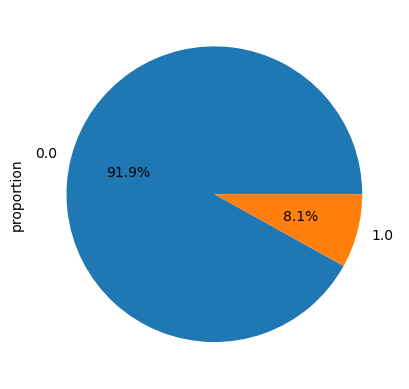

In [16]:
df['TARGET'].value_counts(normalize=True).plot(kind='pie', autopct='%.1f%%')

In [17]:
# Colonnes potentiellement inutiles, faute de variation des valeurs
tmp = df.nunique()
tmp[tmp==1]

BURO_CREDIT_ACTIVE_nan_MEAN                         1
BURO_CREDIT_CURRENCY_nan_MEAN                       1
BURO_CREDIT_TYPE_nan_MEAN                           1
BURO_STATUS_nan_MEAN_MEAN                           1
PREV_NAME_CONTRACT_TYPE_nan_MEAN                    1
PREV_WEEKDAY_APPR_PROCESS_START_nan_MEAN            1
PREV_FLAG_LAST_APPL_PER_CONTRACT_nan_MEAN           1
PREV_NAME_CASH_LOAN_PURPOSE_nan_MEAN                1
PREV_NAME_CONTRACT_STATUS_nan_MEAN                  1
PREV_NAME_PAYMENT_TYPE_nan_MEAN                     1
PREV_CODE_REJECT_REASON_nan_MEAN                    1
PREV_NAME_CLIENT_TYPE_nan_MEAN                      1
PREV_NAME_GOODS_CATEGORY_House Construction_MEAN    1
PREV_NAME_GOODS_CATEGORY_nan_MEAN                   1
PREV_NAME_PORTFOLIO_nan_MEAN                        1
PREV_NAME_PRODUCT_TYPE_nan_MEAN                     1
PREV_CHANNEL_TYPE_nan_MEAN                          1
PREV_NAME_SELLER_INDUSTRY_nan_MEAN                  1
PREV_NAME_YIELD_GROUP_nan_ME

## Préparation des données
### Suppression des variables à une seule modalité

In [18]:
for col in df.columns:
    if df[col].nunique() == 1:
        df = df.drop(columns={col})
    else:
        continue

### Test train split

In [19]:
trainset , testset = train_test_split(df, test_size=0.3, random_state=39)

<Axes: ylabel='proportion'>

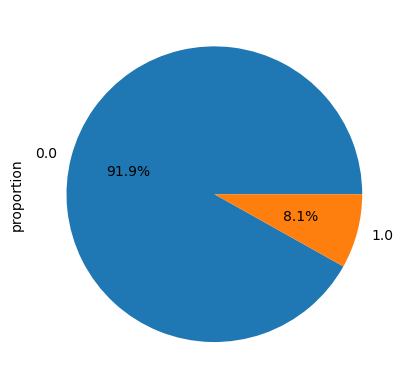

In [20]:
trainset.TARGET.value_counts(normalize=True).plot(kind='pie', autopct='%.1f%%')

Le *trainset* conserve les mêmes proportions de target.

<Axes: ylabel='proportion'>

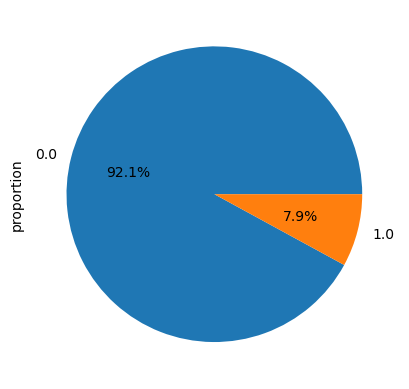

In [21]:
testset.TARGET.value_counts(normalize=True).plot(kind='pie', autopct='%.1f%%')

Le *testset* a une proportion légèrement moindre d'échantillons positifs.

### Fonctions de préparation

In [22]:
def suppression_colonnes_nan(df, taux_nan):
    df = df[df.columns[df.isna().mean() < taux_nan]]
        
    return df

In [23]:
def suppression_identifiant(df):
    return df.drop(columns={'SK_ID_CURR'})

In [24]:
def clean_infini(df):
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    return df

In [68]:
def preparation(df, taux_nan=0.5):
    
    df = suppression_colonnes_nan(df, taux_nan)
    df = suppression_identifiant(df)
    df = clean_infini(df)
    
    X = df.drop(columns={'TARGET'})
    y = df['TARGET']
    
    print(y.value_counts())
    
    return X, y

In [69]:
X_train, y_train = preparation(trainset)

TARGET
0.0    197758
1.0     17496
Name: count, dtype: int64


In [70]:
X_test, y_test = preparation(testset)

TARGET
0.0    84924
1.0     7329
Name: count, dtype: int64


## Fonctions d'évaluation

In [33]:
def confusion(y_test, y_pred):
    """Affiche la matrice de confusion"""
    
    mat = confusion_matrix(y_test, y_pred)
    mat=pd.DataFrame(mat)
    mat.columns = [f"pred_{i}" for i in mat.columns]
    mat.index = [f"test_{i}" for i in mat.index]
    
    return mat

In [34]:
def evaluation(model):
    
    model.fit(X_train, y_train)
    ypred = model.predict(X_test)
    
    matrice_confusion = confusion(y_test, ypred)
    print(matrice_confusion)
    print()
    print(classification_report(y_test, ypred))
    false_positive_rate, true_positive_rate, thresholds = roc_curve(y_test, ypred)
    roc_auc = auc(false_positive_rate, true_positive_rate)
    plt.figure(figsize=(10,10))
    plt.title('Receiver Operating Characteristic')
    plt.plot(false_positive_rate, true_positive_rate, color='red', label = 'AUC = %0.2f' % roc_auc)
    plt.legend(loc = 'lower right')
    plt.plot([0, 1], [0, 1], linestyle='--')
    plt.axis('tight')
    plt.ylabel('True Positive Rate')
    plt.xlabel('False Positive Rate')
    plt.show()

## Modélisation
### Dummy classifier

        pred_0  pred_1
test_0   84924       0
test_1    7329       0

              precision    recall  f1-score   support

         0.0       0.92      1.00      0.96     84924
         1.0       0.00      0.00      0.00      7329

    accuracy                           0.92     92253
   macro avg       0.46      0.50      0.48     92253
weighted avg       0.85      0.92      0.88     92253



C:\ProgramData\anaconda3\envs\Projet7\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\ProgramData\anaconda3\envs\Projet7\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\ProgramData\anaconda3\envs\Projet7\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


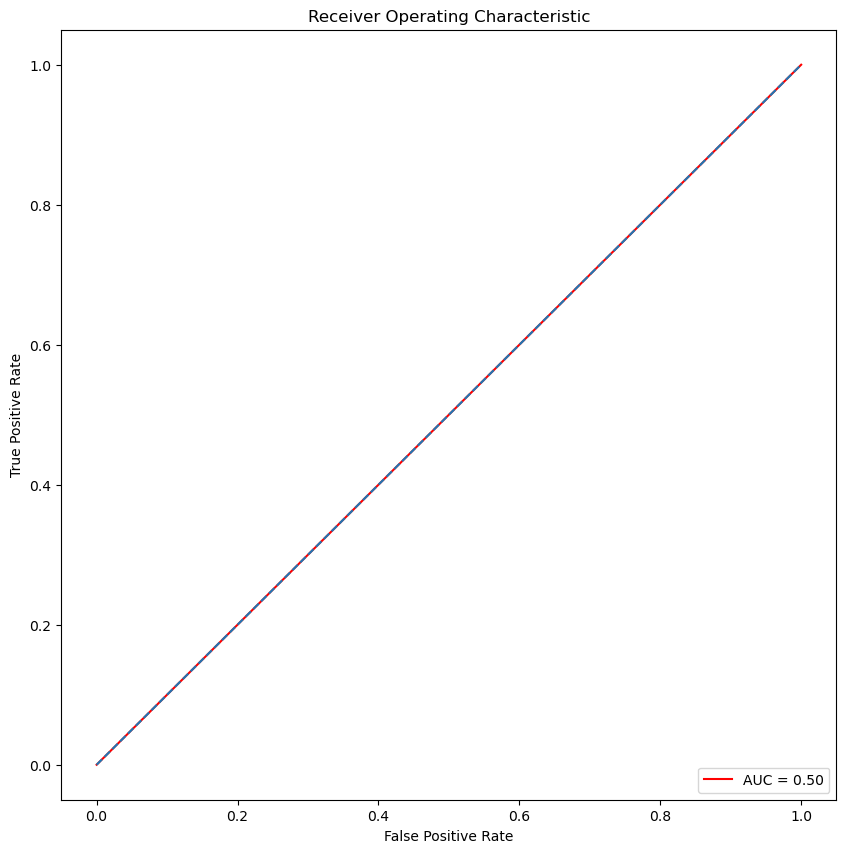

In [35]:
estimator = DummyClassifier(strategy='most_frequent')
evaluation(estimator)

### RandomForest

In [36]:
variables_numeriques = make_column_selector(dtype_include=np.number)

In [37]:
pipeline_numerique = make_pipeline(SimpleImputer(missing_values = np.nan, strategy='median'))

In [38]:
column_transformer = make_column_transformer((pipeline_numerique, variables_numeriques),
                                             n_jobs=-1)

In [65]:
preprocessor = make_pipeline(column_transformer, SelectKBest(f_classif, k=2))

In [66]:
RandomForest = make_pipeline(preprocessor,
                             RandomForestClassifier(class_weight='balanced',
                                                    random_state=39,
                                                    n_jobs=-1))

        pred_0  pred_1
test_0   81058    3866
test_1    6741     588

              precision    recall  f1-score   support

         0.0       0.92      0.95      0.94     84924
         1.0       0.13      0.08      0.10      7329

    accuracy                           0.89     92253
   macro avg       0.53      0.52      0.52     92253
weighted avg       0.86      0.89      0.87     92253



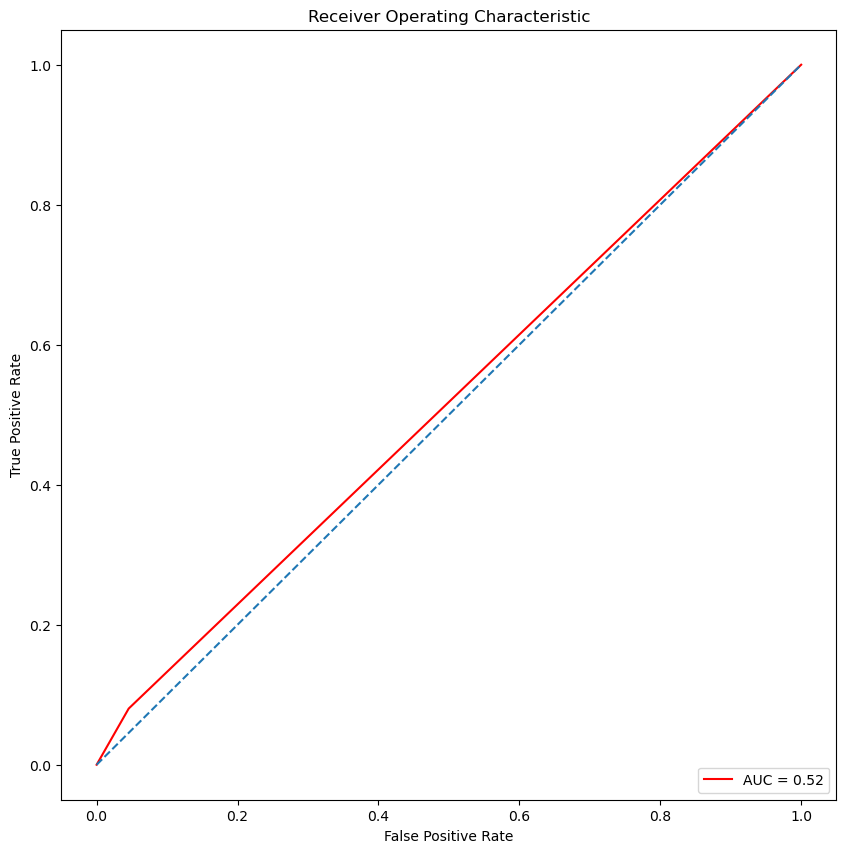

In [71]:
evaluation(RandomForest)

In [61]:
pd.DataFrame(RandomForest.feature_importances_, index=X_train.columns).plot.bar(figsize=(12, 8))

AttributeError: 'Pipeline' object has no attribute 'feature_importances_'

In [ ]:
def score(estimator):
    """Calcule et édite les scores train et test"""
    
    tr_score = estimator.score(X_train, y_train).round(4)
    te_score = estimator.score(X_test, y_test).round(4)
    
    print(f"score train : {tr_score} score test : {te_score}")

In [ ]:
score(estimator)

In [ ]:
pd.Series(y_train).value_counts(normalize=True).round(4)

In [ ]:
pd.Series(y_test).value_counts(normalize=True).round(4)

In [ ]:
DecisionTree = make_pipeline(preprocessor,
                             DecisionTreeClassifier(class_weight='balanced',
                                                    random_state=39))

LogisticRegression = make_pipeline(preprocessor,
                                   StandardScaler(),
                                   LogisticRegression(class_weight='balanced',
                                                      random_state=39,
                                                      n_jobs=-1))

LinearSVC = make_pipeline(preprocessor,
                          StandardScaler(),
                          LinearSVC(class_weight='balanced',
                                    random_state=39))

SVC = make_pipeline(preprocessor,
                    StandardScaler(),
                    SVC(class_weight='balanced',
                        random_state=39))

In [ ]:
dict_of_models = {'RandomForest': RandomForest,
                  'DecisionTree': DecisionTree,
                  'LogisticRegression': LogisticRegression,
                  'LinearSVC': LinearSVC,
                  'SVC': SVC
                 }

In [ ]:
for name, model in dict_of_models.items():
    print(name)
    evaluation(model)

## Simple Logistic regression & Linear SVM
### Logistic Regression